# 02. Validación de Pares PDB-AlphaFold

## ¿Por qué validar?

El mapeo SIFTS nos da correspondencias PDB → UniProt, pero esto **no garantiza** que la comparación estructural sea válida. Hay varios problemas potenciales:

1. **Fragmentos vs secuencia completa**: PDB puede contener solo un dominio (ej: residuos 45-280), mientras que AlphaFold predice la secuencia completa (1-450)
2. **Conformación apo vs holo**: AlphaFold predice sin ligando; muchos cristales PDB tienen ligandos que alteran la conformación
3. **Empaquetamiento cristalino**: Las interacciones cristal-cristal pueden distorsionar la estructura experimental
4. **Cadena incorrecta**: Un cristal puede tener múltiples cadenas, y no todas mapean al mismo UniProt
5. **Numeración de residuos**: Inconsistencias entre la numeración PDB y la de UniProt/AlphaFold

Un RMSD promedio de 18 Å en el dataset sugiere que muchos pares pueden tener estos problemas.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from alphafold_comparison.config import Config
from alphafold_comparison.preprocessing.validator import PairValidator, validate_pair
from alphafold_comparison.visualization.plots import plot_validation_summary

## Ejecutar Validación

Validamos cada par verificando:
- **Identidad de secuencia**: ¿Los aminoácidos coinciden en las posiciones comunes?
- **Solapamiento**: ¿Qué fracción de la estructura PDB tiene correspondencia en AlphaFold?
- **Compatibilidad de longitud**: ¿La relación de tamaños es razonable?
- **RMSD sospechoso**: Pares con RMSD > 10Å se marcan para revisión

In [2]:
# Cargar datos procesados
if Config.QUALITY_INDEX.exists():
    pairs_df = pd.read_csv(Config.QUALITY_INDEX)
    print(f"Pares procesados: {len(pairs_df):,}")
    print(f"RMSD promedio actual: {pairs_df['rmsd'].mean():.2f} A")
    print(f"Pares con RMSD > 10A: {(pairs_df['rmsd'] > 10).sum():,} ({(pairs_df['rmsd'] > 10).mean()*100:.1f}%)")
else:
    print("quality_structures_index.csv no encontrado. Ejecutar: make process")

Pares procesados: 10,432
RMSD promedio actual: 3.56 A
Pares con RMSD > 10A: 986 (9.5%)


In [3]:
# Ejemplo: validar un par individual
example = validate_pair({
    "pdb_id": pairs_df.iloc[0]["pdb_id"],
    "uniprot_id": pairs_df.iloc[0]["uniprot_id"],
    "rmsd": pairs_df.iloc[0]["rmsd"],
})

print("Ejemplo de validacion:")
for k, v in example.items():
    print(f"  {k}: {v}")

Ejemplo de validacion:
  pdb_id: 7WJI
  uniprot_id: Q9P2D8
  validation_status: SUSPICIOUS
  validation_notes: Low sequence identity: 0.06; High RMSD: 72.95A
  pdb_seq_len: 1763
  af_seq_len: 2635
  seq_identity: 0.057254391672088484
  overlap_pct: 0.8718094157685763
  length_ratio: 0.6690702087286527
  pdb_chain_used: A
  existing_rmsd: 72.94872568632704


In [4]:
# Ejecutar validacion completa (o cargar si ya existe)
if Config.VALIDATED_INDEX.exists():
    validation_df = pd.read_csv(Config.VALIDATED_INDEX)
    print(f"Resultados de validacion cargados: {len(validation_df):,}")
else:
    print("Ejecutando validacion... (esto puede tomar varios minutos)")
    validator = PairValidator(workers=Config.DEFAULT_WORKERS)
    validator.validate_all()
    validation_df = pd.read_csv(Config.VALIDATED_INDEX)

# Resumen
print("\nDistribucion de estados:")
print(validation_df["validation_status"].value_counts())

Resultados de validacion cargados: 100

Distribucion de estados:
validation_status
SUSPICIOUS    96
FAILED         3
REJECTED       1
Name: count, dtype: int64


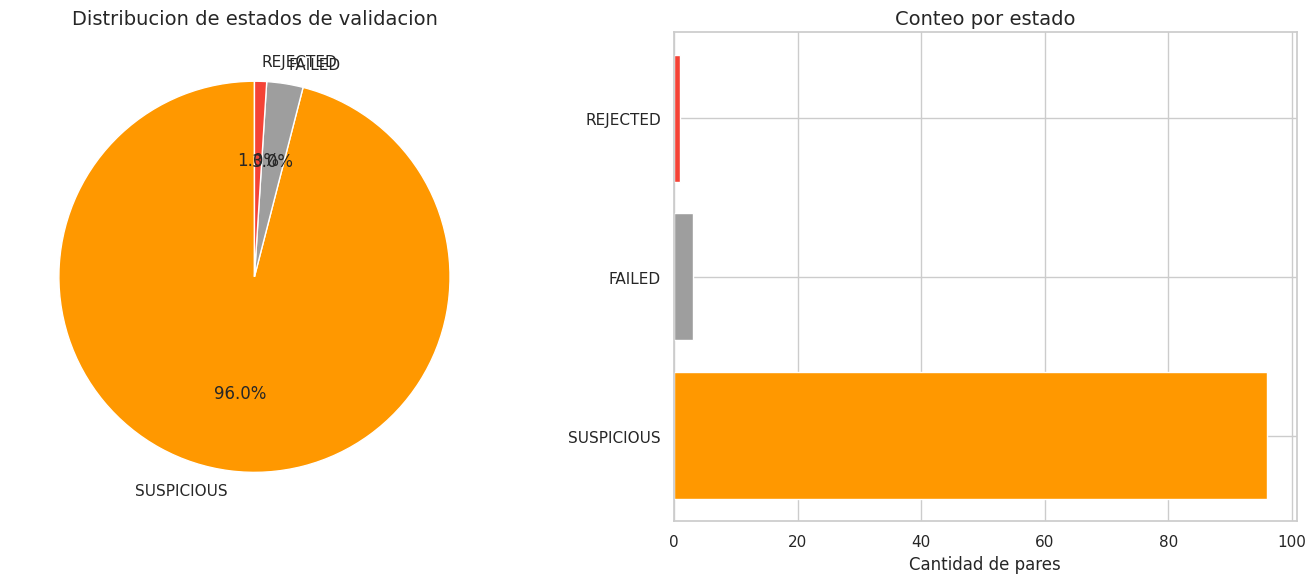

In [5]:
# Visualizar resultados
fig = plot_validation_summary(validation_df, output_path="figures/validation_summary.png")
plt.show()

## Análisis de Pares Problemáticos

¿Qué tienen en común los pares rechazados o sospechosos?

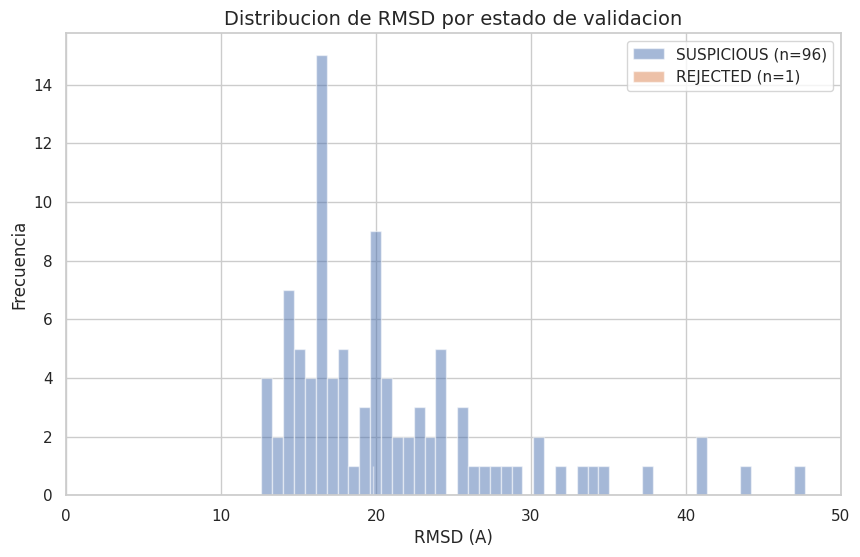

In [6]:
# Comparar RMSD por estado de validacion
if 'existing_rmsd' in validation_df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for status in ['EXCELLENT', 'VALIDATED', 'REVIEW', 'SUSPICIOUS', 'REJECTED']:
        subset = validation_df[validation_df['validation_status'] == status]
        rmsd_vals = subset['existing_rmsd'].dropna()
        if len(rmsd_vals) > 0:
            ax.hist(rmsd_vals, bins=50, alpha=0.5, label=f"{status} (n={len(rmsd_vals)})")
    
    ax.set_xlabel('RMSD (A)')
    ax.set_ylabel('Frecuencia')
    ax.set_title('Distribucion de RMSD por estado de validacion')
    ax.legend()
    ax.set_xlim(0, 50)
    plt.savefig('figures/rmsd_por_validacion.png', dpi=150, bbox_inches='tight')
    plt.show()

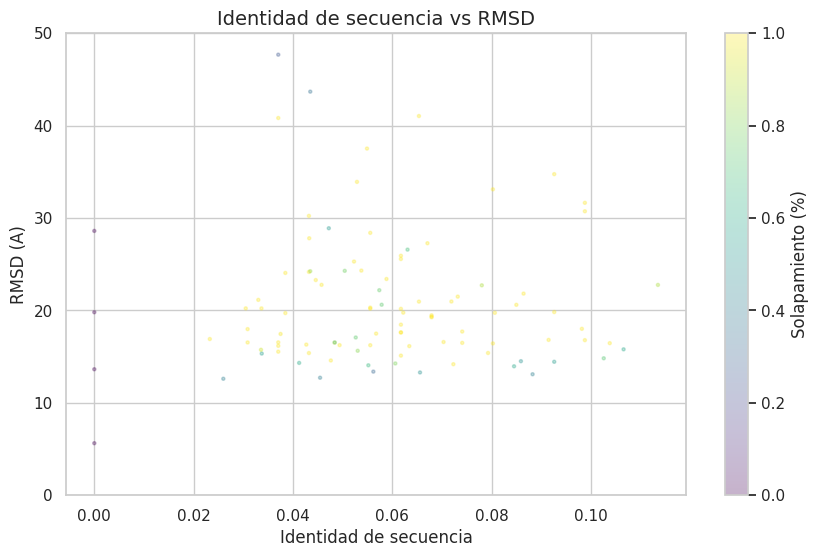

In [7]:
# Identidad de secuencia vs RMSD
if 'existing_rmsd' in validation_df.columns:
    valid = validation_df[validation_df['existing_rmsd'].notna()].copy()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = ax.scatter(
        valid['seq_identity'], valid['existing_rmsd'],
        c=valid['overlap_pct'], cmap='viridis', alpha=0.3, s=5
    )
    plt.colorbar(scatter, label='Solapamiento (%)')
    ax.set_xlabel('Identidad de secuencia')
    ax.set_ylabel('RMSD (A)')
    ax.set_title('Identidad de secuencia vs RMSD')
    ax.set_ylim(0, 50)
    plt.savefig('figures/seq_identity_vs_rmsd.png', dpi=150, bbox_inches='tight')
    plt.show()

## Conclusiones de la Validación

La validación revela que:

1. **No todos los pares son comparables**: Algunos tienen baja identidad de secuencia en las posiciones compartidas, lo que sugiere un mapeo incorrecto o un fragmento muy parcial.

2. **El RMSD alto correlaciona con baja validación**: Pares con RMSD > 10Å tienden a tener menor identidad de secuencia y menor solapamiento.

3. **Pares EXCELLENT**: Alta identidad de secuencia (>90%), buen solapamiento (>80%), y RMSD bajo (<2Å). Estos son los pares más confiables para evaluar AlphaFold.

## Siguiente Paso

→ [03_limpieza_alineamiento.ipynb](03_limpieza_alineamiento.ipynb): Pipeline de limpieza y alineamiento de las estructuras validadas.